In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("D:/Top mentor/Machine learning/Machine learning assinments/Clustering  - Assignment 6/5. Clustering/crime_data.csv")
data.head(5)

,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [3]:
data.shape

(50, 5)

In [4]:
data.columns

Index(['City', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [5]:
data['City'].nunique()

50

In [6]:
X = data.drop(['City'], axis = 1)
X

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6
5,7.9,204,78,38.7
6,3.3,110,77,11.1
7,5.9,238,72,15.8
8,15.4,335,80,31.9
9,17.4,211,60,25.8


In [16]:
X1 = data[['Murder','Assault', 'UrbanPop', 'Rape']]
X1

,Murder,Assault,UrbanPop,Rape
0,13.2,236,58,21.2
1,10.0,263,48,44.5
2,8.1,294,80,31.0
3,8.8,190,50,19.5
4,9.0,276,91,40.6
5,7.9,204,78,38.7
6,3.3,110,77,11.1
7,5.9,238,72,15.8
8,15.4,335,80,31.9
9,17.4,211,60,25.8


In [8]:
from sklearn.cluster import KMeans

In [31]:
km = KMeans(n_clusters=3)

In [32]:
km.fit(X1)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [33]:
pred = km.predict(X1)
pred

array([2, 0, 0, 2, 0, 2, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 1, 2,
       1, 0, 2, 1, 1, 2, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1, 2, 2, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [34]:
data['cluster_3']= pred

In [35]:
data.head(5)

,City,Murder,Assault,UrbanPop,Rape,cluster_5,cluster_3
0,Alabama,13.2,236,58,21.2,1,2
1,Alaska,10.0,263,48,44.5,1,0
2,Arizona,8.1,294,80,31.0,4,0
3,Arkansas,8.8,190,50,19.5,2,2
4,California,9.0,276,91,40.6,4,0


In [23]:
import seaborn as sns

<Axes: xlabel='Murder', ylabel='Assault'>

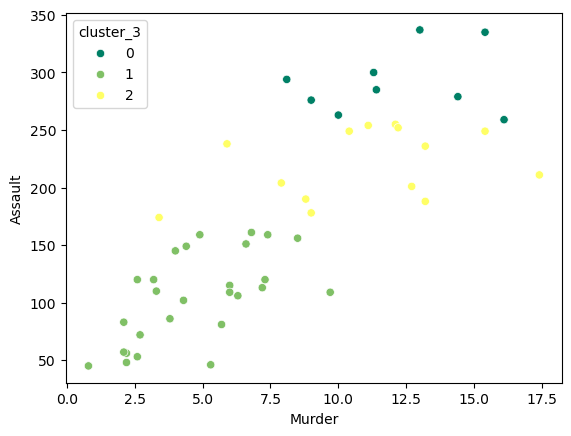

In [36]:
sns.scatterplot(x = 'Murder', y ="Assault", data = data, hue = 'cluster_3', palette='summer' )

In [38]:
data[data['cluster_3']==1]

,City,Murder,Assault,UrbanPop,Rape,cluster_5,cluster_3
6,Connecticut,3.3,110,77,11.1,0,1
10,Hawaii,5.3,46,83,20.2,3,1
11,Idaho,2.6,120,54,14.2,0,1
13,Indiana,7.2,113,65,21.0,0,1
14,Iowa,2.2,56,57,11.3,3,1
15,Kansas,6.0,115,66,18.0,0,1
16,Kentucky,9.7,109,52,16.3,0,1
18,Maine,2.1,83,51,7.8,3,1
20,Massachusetts,4.4,149,85,16.3,2,1
22,Minnesota,2.7,72,66,14.9,3,1


In [28]:
from math import sqrt
sqrt(len(data)/2)  #### Rule of Thumb

5.0

In [29]:

wcss = []
k = range(1,6)
for i in k:
  km = KMeans(n_clusters=i)
  km.fit(X)
  wcss.append(km.inertia_)
print(wcss)

[355807.8216, 96399.02814449917, 47964.26535714285, 37740.5887032967, 25396.189714285716]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

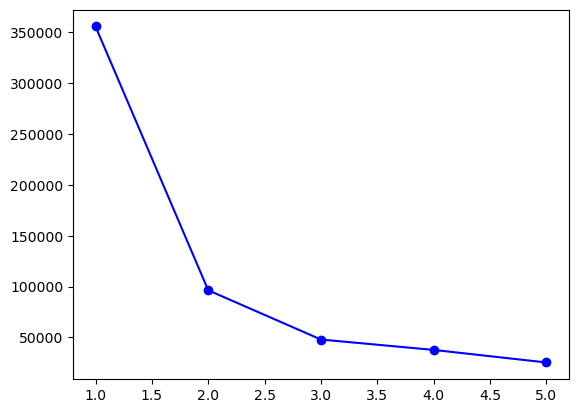

In [30]:
import matplotlib.pyplot as plt
plt.plot(k,wcss,'bo-' )

In [39]:
from sklearn.metrics import silhouette_score

In [40]:
score= silhouette_score(X, pred)
print(score)

0.443084639204531


## Assignment - EastWestAirlines

In [55]:
data1 = pd.read_csv("D:/Top mentor/Machine learning/Machine learning assinments/Clustering  - Assignment 6/EastWestAirlines-Description,EastWestAirlines-data/EastWestAirlines-data.csv")
data1.head(5)

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [50]:
data1.shape

(3999, 12)

In [51]:
data1.columns

Index(['ID', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award'],
      dtype='object')

In [52]:
data1.isnull().sum()

ID                   0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award                0
dtype: int64

In [57]:
X1 = data1.drop(['ID'], axis =1)
X1.head(5)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [59]:
km1 = KMeans(n_clusters=5)

In [60]:
km.fit(X1)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [61]:
pred = km.predict(X1)
pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3999,), dtype=int32)

In [62]:
data1['cluster_5'] = pred

In [63]:
data1

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award,cluster_5
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1,0
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1,0
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1,0
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0,0


<Axes: xlabel='Balance', ylabel='Bonus_miles'>

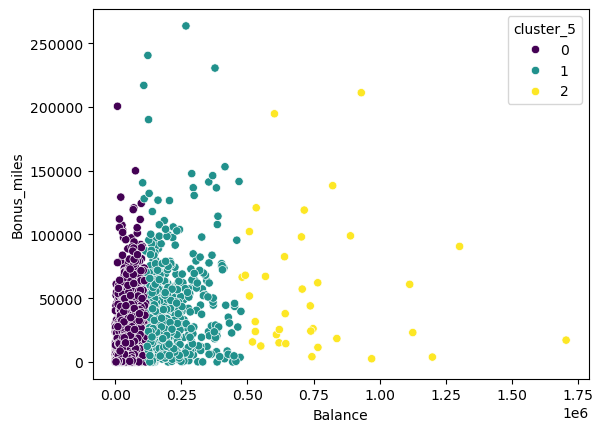

In [69]:
sns.scatterplot(x = 'Balance', y = 'Bonus_miles', data = data1, palette='viridis', hue = 'cluster_5')

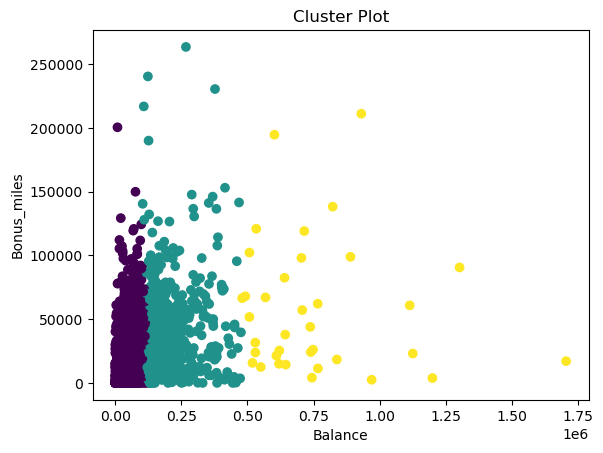

In [67]:
import matplotlib.pyplot as plt

plt.scatter(
    data1['Balance'],
    data1['Bonus_miles'],
    c=data1['cluster_5'],
    cmap='viridis',
)

plt.xlabel('Balance')
plt.ylabel('Bonus_miles')
plt.title('Cluster Plot')
plt.show()

In [68]:
score1 = silhouette_score(X1, pred)
score1

0.6575796574325113